# Data Challenge 8 — Introduction to Multiple Linear Regression (MLR)


**Format:** Instructor Guidance → You Do (Students) → We Share (Reflection)


**Goal:** Build an **MLR** model using **2–3 predictors** to predict one numeric target. Evaluate with a **train–test split** (MAE/RMSE), interpret **coefficients while holding others constant**, and compare against an **SLR baseline**.


> Dataset: **NYC Yellow Taxi — Dec 2023** (CSV). Keep code *simple*: light numeric coercion only for your chosen columns.

## Instructor Guidance

**Docs (quick links):**
- Train/Test Split — scikit‑learn: https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html
- MAE / MSE / RMSE — scikit‑learn: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.mean_absolute_error.html
- OLS (fit/predict/residuals) — statsmodels: https://www.statsmodels.org/stable/generated/statsmodels.regression.linear_model.OLS.html
- OLS Results (`resid`, `fittedvalues`, `summary`) — statsmodels: https://www.statsmodels.org/stable/generated/statsmodels.regression.linear_model.RegressionResults.html
- Q–Q plot — SciPy: https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.probplot.html


### Pseudocode Plan (for **MLR**)
1) **Load CSV** → preview columns/shape.
2) **Assign Y and Xs (2–3 predictors)** → pick numeric columns that matter; if needed, coerce **just** these to numeric and drop NAs.
3) **Add intercept** → `X = add_constant(X_matrix)`.
4) **Train–test split (80/20)** → `X_train, X_test, y_train, y_test = train_test_split(...)` (set `random_state`).
5) **Fit on TRAIN** → `model = OLS(y_train, X_train).fit()`.
6) **Predict on TEST** → `y_pred = model.predict(X_test)`.
7) **Evaluate on TEST** → compute **MAE** and **RMSE** using `y_test` & `y_pred`; speak in **units of Y**.
8) **Diagnostics on TRAIN** → use `model.resid` & `model.fittedvalues` for residuals vs fitted; Q–Q plot; check Durbin–Watson in `model.summary()`.
9) **Bias–variance read (optional)** → compare train vs test errors.
10) **Stakeholder one‑liner** → MAE/RMSE in units + brief reliability note. *(Optional)* Contrast with an **SLR baseline** using the strongest single predictor.

## You Do — Student Section
Work in pairs. Keep code simple and comment your choices.

### Step 0 — Setup & Imports

In [2]:
import pandas as pd, numpy as np
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import scipy.stats as stats
from pathlib import Path
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

### Step 1 — Load CSV & Preview
- Point to your **Dec 2023** taxi CSV.
- Print **shape** and **columns**.

**Hint: You may have to drop missing values and do a force coercion to make sure the variables stay numeric (other coding assignments may help)**

In [3]:
df = pd.read_csv('/Users/Marcy_Student/Desktop/2023_Yellow_Taxi_Trip_Data_20251015.csv', low_memory= False)
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
0,2,12/01/2023 04:11:39 PM,12/01/2023 04:19:13 PM,2.0000,0.69,1.0000,N,141,140,1,7.9,2.5000,0.5000,3,0.0000,1.0000,17.4,2.5000,0.0000
1,1,12/01/2023 04:11:39 PM,12/01/2023 04:20:41 PM,3.0000,1.1,1.0000,N,236,263,2,10,5.0000,0.5000,0,0.0000,1.0000,16.5,2.5000,0.0000
2,2,12/01/2023 04:11:39 PM,12/01/2023 04:20:38 PM,1.0000,1.57,1.0000,N,48,239,4,-10.7,-2.5000,-0.5000,0,0.0000,-1.0000,-17.2,-2.5000,0.0000
3,2,12/01/2023 04:11:39 PM,12/01/2023 04:20:38 PM,1.0000,1.57,1.0000,N,48,239,4,10.7,2.5000,0.5000,0,0.0000,1.0000,17.2,2.5000,0.0000
4,1,12/01/2023 04:11:39 PM,12/01/2023 04:34:39 PM,2.0000,3,1.0000,N,164,211,1,21.9,5.0000,0.5000,3,0.0000,1.0000,31.4,2.5000,0.0000


### Step 2 —  Pick Target **Y** and Predictors **Xs** (choose 2–3 numeric)

- **Avoid** using an X that directly defines Y (e.g., `total_amount` when Y = `fare_amount`).
- Coerce **only these columns** to numeric; drop NA rows.

In [4]:
# converting to numeric
num_cols = ['fare_amount', 'tip_amount', 'trip_distance','total_amount','passenger_count']
for c in num_cols:
    df[c] = pd.to_numeric(
        df[c].astype(str).str.strip().str.replace(r'[^0-9.+\-eE]', '', regex=True),
        errors='coerce'
    )
df = df[(df['fare_amount'] > 0) & (df['trip_distance'] > 0) & (df['passenger_count'] > 0)]
df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=num_cols)
def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.10)
    Q3 = df[column].quantile(0.90)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

df = remove_outliers_iqr(df, 'fare_amount')
df = remove_outliers_iqr(df, 'trip_distance')
y = df['fare_amount']
Xs = df[['trip_distance','passenger_count']]

### Step 3 —  Design Matrix (add intercept) & Train–Test Split (80/20)

- Add intercept with `sm.add_constant`.
- Use a **random_state** for reproducibility.
- (Optional) Discuss when a **time‑aware** split is better.

In [ ]:
y = df['fare_amount']
X = sm.add_constant(Xs)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,
    random_state= 42,
    shuffle= True       
)

X_train = sm.add_constant(X_train)
X_test = sm.add_constant(X_test)

### Step 4 — Fit MLR on TRAIN & Interpret Coefficients (holding others constant)

- Print the **coefficient table**.
- Write **one unit‑based sentence per coefficient** using “**holding others constant**.”

In [6]:
# Fit the model
model = sm.OLS(y_train, X_train).fit()
y_pred = model.predict(X_test)

model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            fare_amount   R-squared:                       0.874
Model:                            OLS   Adj. R-squared:                  0.874
Method:                 Least Squares   F-statistic:                 8.267e+06
Date:                Tue, 04 Nov 2025   Prob (F-statistic):               0.00
Time:                        09:44:59   Log-Likelihood:            -7.4423e+06
No. Observations:             2386524   AIC:                         1.488e+07
Df Residuals:                 2386521   BIC:                         1.488e+07
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
===================================================================================
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               7.0407      0.007    987.973      0.000       7.027       7.055
trip_distance       3.7107      0.001   4059.668      0.000       3.709       3.713
passenger_count     0.2629      0.004     66.995      0.000       0.255       0.271
==============================================================================
Omnibus:                  2249227.471   Durbin-Watson:                   2.000
Prob(Omnibus):                  0.000   Jarque-Bera (JB):        191700367.615
Skew:                           4.344   Prob(JB):                         0.00
Kurtosis:                      46.039   Cond. No.                         11.3
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

*Template (edit to your variables & units):*
- **β_intercept (const):** the fare amount baseline is $7 when both predictors(distance and passenger) are 0. This is a mathematical anchor.
- **β_X1:** Holding passenger count constant, +1 mile in **trip distance** is associated with **+$3.7** in **fare amount**.
- **β_X2:** Holding trip distance constant, +1 person in **passenger count** is associated with only **+0.26 dollar** in **fare amount**.
- *(If 3rd predictor)* **β_X3:** …
- **Significance:** Note **p‑values** and **95% CIs** (from statsmodels summary) if relevant.\
the P_value ~0 for both X variables indicates a significant relationship between the features. with a high power R_squared, 87%, this model explains much of the variation observed in the data... However the confidence interval is wide, suggesting uncertainty on how significant the relationship is.

### Step 5 — Evaluate on **Unseen Test Data** (MAE/RMSE in units of Y)
Compute MAE and RMSE and write a one‑sentence **stakeholder** readout.

In [ ]:
# Calculate MAE and RMSE

test_mae = mean_absolute_error(y_test, y_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"MAE: ${test_mae:.2f}")
print(f"RMSE: ${test_rmse:.2f}")

MAE: $3.46
RMSE: $5.52


### Step 6 — (Optional) Compare to an SLR Baseline
- Fit **SLR** using your strongest single predictor (e.g., `trip_distance`).
- Compare **MAE/RMSE** to your **MLR**; explain why MLR helped (or didn’t).

In [ ]:
x_slr = sm.add_constant(df['trip_distance'])
model_slr = sm.ols(y,x_slr).fit()

## not finished

### Step 7 — Quick Diagnostics (Train Residuals)
- **Residuals vs Fitted:** random cloud ≈ good; cones/funnels suggest non‑constant variance.
- **Q–Q plot:** points roughly along diagonal (normality for inference).
- **Durbin–Watson:** printed in `model.summary()` (~2 suggests independence).

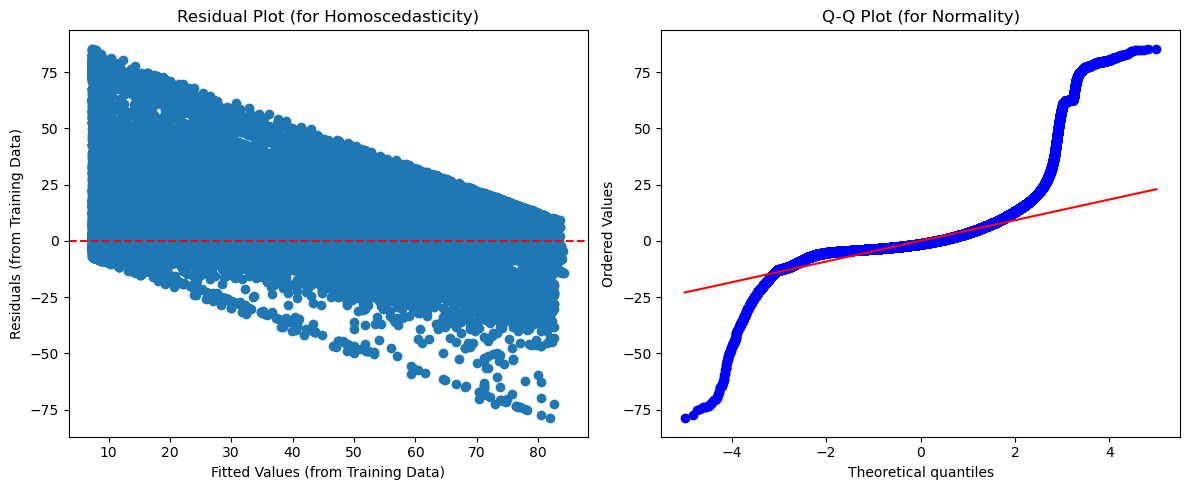

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            fare_amount   R-squared:                       0.874
Model:                            OLS   Adj. R-squared:                  0.874
Method:                 Least Squares   F-statistic:                 8.267e+06
Date:                Tue, 04 Nov 2025   Prob (F-statistic):               0.00
Time:                        10:26:00   Log-Likelihood:            -7.4423e+06
No. Observations:             2386524   AIC:                         1.488e+07
Df Residuals:                 2386521   BIC:                         1.488e+07
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
===================================================================================
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               7.0407      0.007    987.973      0.000       7.027       7.055
trip_distance       3.7107      0.001   4059.668      0.000       3.709       3.713
passenger_count     0.2629      0.004     66.995      0.000       0.255       0.271
==============================================================================
Omnibus:                  2249227.471   Durbin-Watson:                   2.000
Prob(Omnibus):                  0.000   Jarque-Bera (JB):        191700367.615
Skew:                           4.344   Prob(JB):                         0.00
Kurtosis:                      46.039   Cond. No.                         11.3
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [7]:
residuals = model.resid
fitted = model.fittedvalues
# 1. Plot for Homoscedasticity
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(fitted, residuals)
plt.axhline(0, color='red', linestyle='--')
plt.title('Residual Plot (for Homoscedasticity)')
plt.xlabel('Fitted Values (from Training Data)')
plt.ylabel('Residuals (from Training Data)')

# 2. Q-Q Plot for Normality
plt.subplot(1, 2, 2)
stats.probplot(residuals, dist="norm", plot=plt)
plt.title('Q-Q Plot (for Normality)')

plt.tight_layout()
plt.show()
model.summary()

## We Share — Reflection & Wrap‑Up
Write **2 short paragraphs** and be specific:


1) **Which model would you trust today—MLR or SLR—and why?**
Use **test MAE/RMSE (units)**, coefficient interpretations (holding others constant), and any residual/correlation observations.
- Predicting fare amount based on trip distance using a simple linear regression model resulted in a mean absolute error of 3.61, which is about 18 to 19 % in average. adding passenger count into action, and modeling with a multiple Regression Model slighlty reduced that error to $3.46... our predictor goes from being off by 3.61 to 3.46, which made it slighly better, given that the power, p_value and confidence interval stay almost the same.

2) **What’s next to improve reliability?**
Options: add a more relevant predictor, use a **time‑aware split**, segment by ride type (airport vs. city), or prepare for **VIF/regularization** to handle collinearity.
- Adding more relevant predictor will be a good way to improve reliability, passenger count is probabily not the best predictor here as it has little impact in the model performance... using interactions features and transforming data such as scaling features before modeling is likely one of the best way to improve the model. For example the range of passengers is 1-5, while distance can go way above, the model tends probabibly to prioritize distance of passenger count... But in this context, we are aware that fare amount do not really depend on passenger count.